# Intervention measures

`Odds`, `AvgOdds`, `MaxAvgOdds` — from CausalGym ([Arora, Jurafsky & Potts, ACL 2024](https://aclanthology.org/2024.acl-long.785.pdf), §3.4), computed from one run's CSV.

Each row is one intervention on one example. Every `logp` column is a  **log-probability of a single token**

| column | is |
|---|---|
| `base_logp_A` | log p(A \| base prompt), no intervention |
| `base_logp_B` | log p(B \| base prompt), no intervention |
| `base_intervention_logp_A` | log p(A \| base prompt, after patching) |
| `base_intervention_logp_B` | log p(B \| base prompt, after patching) |
| `source_logp_A` / `source_logp_B` | same, but the source prompt |

**`A` is the token that agrees with the source** `B` agrees with the base.

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUN = "../../results/interp/main_runs/Qwen3-VL-2B-Instruct/vision/target_verb_att0_opp"

def load(path):
    d = pd.read_csv(path)
    return d[d["error"].isna()].copy()

d = load(f"{RUN}/das.csv")
d.head()

,split,inverse,tok,layer,source_input,base_input,source_logp_A,source_logp_B,base_logp_A,base_logp_B,base_intervention_logp_A,base_intervention_logp_B,error
0,train,0,4,1,The sleepy bat,The sleepy bats,-1.807923,-9.932923,-8.388176,-1.638176,-8.388176,-1.638176,NaN
1,train,1,4,1,The sleepy bats,The sleepy bat,-1.638176,-8.388176,-9.932923,-1.807923,-9.932923,-1.807923,NaN
2,train,0,4,1,The fuzzy frog,The fuzzy frogs,-11.715403,-14.527903,-15.608815,-11.515065,-15.608815,-11.515065,NaN
3,train,1,4,1,The fuzzy frogs,The fuzzy frog,-11.515065,-15.608815,-14.527903,-11.715403,-14.527903,-11.715403,NaN
4,train,0,4,1,The bright shark,The bright sharks,-8.277756,-10.902756,-11.324597,-8.762097,-11.324597,-8.762097,NaN


## Odds

Per row. A **ratio of two odds**: how much the model favoured the base label before the edit, times how much it favours the source label after.

$$\mathrm{Odds} = \log\left[\frac{p(y_b \mid b)}{p(y_s \mid b)} \cdot \frac{p^{*}(y_s \mid b,s)}{p^{*}(y_b \mid b,s)}\right]$$



In [ ]:
def odds(d): #EXTRACT ODDS
    before = d["base_logp_B"] - d["base_logp_A"]
    after = d["base_intervention_logp_A"] - d["base_intervention_logp_B"]
    return before + after

d["odds"] = odds(d)
d[["split", "layer", "tok", "odds"]].head()

,split,layer,tok,odds
0,train,1,4,0.0
1,train,1,4,0.0
2,train,1,4,0.0
3,train,1,4,0.0
4,train,1,4,0.0


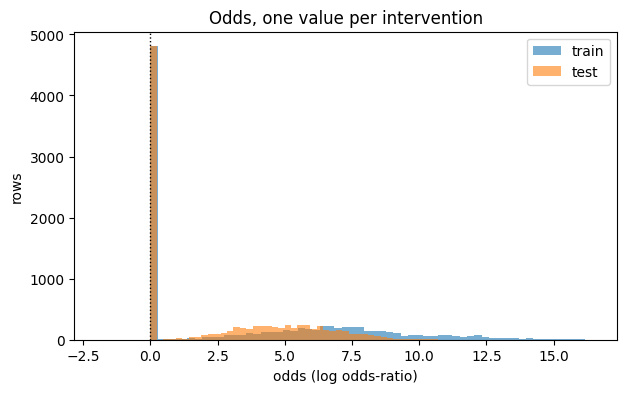

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
for split, c in [("train", "tab:blue"), ("test", "tab:orange")]:
    ax.hist(d[d["split"] == split]["odds"], bins=60, alpha=.6, color=c, label=split)
ax.axvline(0, color="k", lw=1, ls=":")
ax.set_xlabel("odds (log odds-ratio)")
ax.set_ylabel("rows")
ax.set_title("Odds, one value per intervention")
ax.legend()
plt.show()

## AvgOdds

Mean `odds` over all examples at one **(layer, tok)** site. One scalar per site, so the whole run becomes a grid.

In [ ]:
def avg_odds(d): #GET AVG ODDS
    return d.groupby(["layer", "tok"])["odds"].mean().unstack("tok").sort_index()

avg_odds(d[d["split"] == "test"]).round(2)

tok,4,5
layer,,
1,0.0,4.37
5,0.0,4.99
10,0.0,4.93
15,0.0,5.07
20,0.0,5.68
25,0.0,5.72


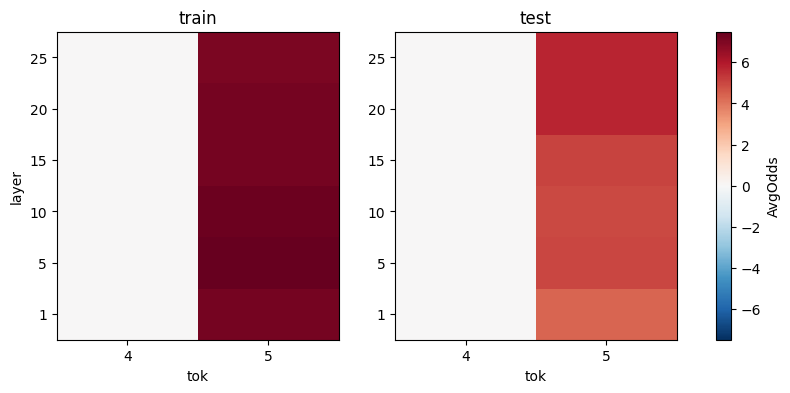

In [ ]:
grids = {s: avg_odds(d[d["split"] == s]) for s in ("train", "test")} 
vmax = max(abs(g.values).max() for g in grids.values()) # ARGMAX AVGODDS

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split, g) in zip(axes, grids.items()):
    im = ax.imshow(g.values, aspect="auto", cmap="RdBu_r", origin="lower", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(g.columns)), g.columns)
    ax.set_yticks(range(len(g.index)), g.index)
    ax.set_xlabel("tok")
    ax.set_title(split)
axes[0].set_ylabel("layer")
fig.colorbar(im, ax=axes, label="AvgOdds")
plt.show()

## MaxAvgOdds

The best cell of the grid — one number per run, so runs can be compared.

In [27]:
def max_avg_odds(d):
    g = d.groupby(["layer", "tok"])["odds"].mean()
    return g.max(), g.idxmax()

max_avg_odds(d[d["split"] == "test"])

(5.720190429240465, (25, 5))

In [28]:
METHODS = ["das", "diffmean", "probe"]

rows = []
for m in METHODS:
    md = load(f"{RUN}/{m}.csv")
    md["odds"] = odds(md)
    for split in ("train", "test"):
        v, cell = max_avg_odds(md[md["split"] == split])
        rows.append(dict(method=m, split=split, max_avg_odds=v, layer=cell[0], tok=cell[1]))

summary = pd.DataFrame(rows)
summary.round(2)

,method,split,max_avg_odds,layer,tok
0,das,train,7.49,5,5
1,das,test,5.72,25,5
2,diffmean,train,7.12,10,5
3,diffmean,test,4.88,10,5
4,probe,train,6.67,10,5
5,probe,test,4.81,10,5


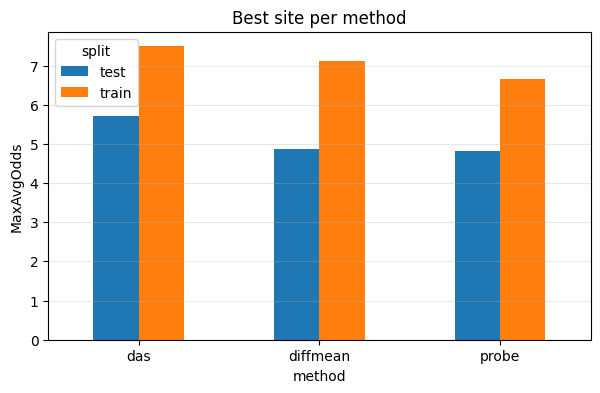

In [29]:
piv = summary.pivot(index="method", columns="split", values="max_avg_odds").loc[METHODS]

ax = piv.plot.bar(figsize=(7, 4), color=["tab:blue", "tab:orange"], rot=0)
ax.set_ylabel("MaxAvgOdds")
ax.set_title("Best site per method")
ax.grid(axis="y", alpha=.3)
plt.show()